# KamiLimu Data Science Statistics Unplugged
### A hands-on, in-depth walkthrough of Descriptive Statistics, Probability Theory, and Hypothesis Testing

**How this notebook works**

- Each concept is introduced with intuition first, math second, and code third.
- Every code cell is meant to be *run and messed with* — change the numbers, re-run, see what breaks.
- Scattered through the notebook are **🎨 Excalidraw Breaks**. These are deliberate pauses: stop coding, open [excalidraw.com](https://excalidraw.com), and hand-draw the picture described. Drawing a bell curve or a Venn diagram yourself builds intuition that reading never will. There's a checklist in each break of exactly what your sketch should contain.
- At the end of each of the three parts there's a **Mentees Lab** — a set of exercises with blank code cells (`# TODO`) for you to fill in.
- A final **Capstone** ties all three topics together using one realistic dataset.

Let's get into it.


In [4]:
# Setup — run this first
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

np.random.seed(42)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (8, 5)
print("Environment ready.")

ModuleNotFoundError: No module named 'numpy'

---
# Part 1 — Descriptive Statistics

**The core idea:** raw data is too big for a human brain to hold at once. Descriptive statistics are *compression algorithms* — they take a pile of numbers and hand you back a small set of numbers that summarize the shape, center, and spread of the pile, at the cost of losing detail.

Every summary statistic is a trade: what does it keep, and what does it throw away?


## 1.1 Measures of Central Tendency — "where is the middle?"

| Measure | Definition | Sensitive to outliers? | Best for |
|---|---|---|---|
| **Mean** ($\bar{x} = \frac{1}{n}\sum x_i$) | Arithmetic average | Very | Symmetric data |
| **Median** | Middle value when sorted | No | Skewed data, outliers present |
| **Mode** | Most frequent value | No | Categorical / multimodal data |

The mean is the "center of mass" — literally, if you placed each data point as a weight on a ruler, the mean is where it balances. That's exactly why one huge outlier can drag it far from where "most" of the data sits.


In [ ]:
# A symmetric dataset vs. a skewed one (e.g. incomes)
symmetric_data = np.random.normal(loc=50, scale=10, size=1000)
skewed_data = np.random.exponential(scale=20, size=1000) + 20  # mimics income-like skew

for name, data in [("Symmetric", symmetric_data), ("Skewed (income-like)", skewed_data)]:
    mean = np.mean(data)
    median = np.median(data)
    mode = stats.mode(np.round(data), keepdims=True).mode[0]
    print(f"{name:22s} | mean={mean:7.2f}  median={median:7.2f}  mode≈{mode:7.2f}")


Symmetric              | mean=  50.19  median=  50.25  mode≈  52.00
Skewed (income-like)   | mean=  40.16  median=  34.52  mode≈  21.00


Notice: for the symmetric data, mean ≈ median. For the skewed data, the mean gets pulled toward the long tail while the median stays anchored to where the bulk of the data actually is. **This is why median household income, not mean, is the standard economic statistic** — a handful of billionaires would otherwise distort the "typical" household picture.


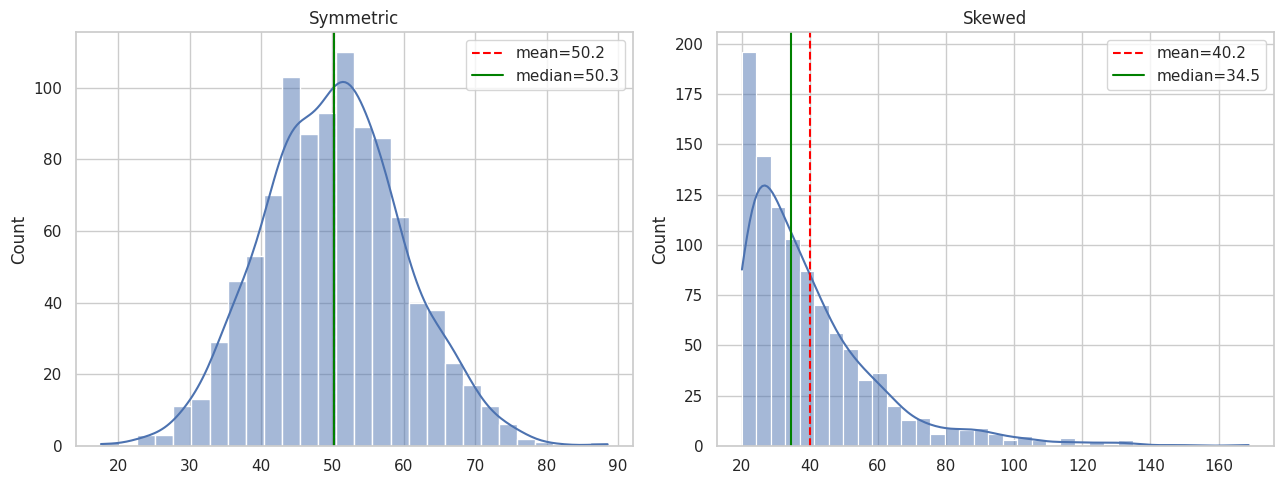

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (name, data) in zip(axes, [("Symmetric", symmetric_data), ("Skewed", skewed_data)]):
    sns.histplot(data, kde=True, ax=ax, color="#4C72B0")
    ax.axvline(np.mean(data), color="red", linestyle="--", label=f"mean={np.mean(data):.1f}")
    ax.axvline(np.median(data), color="green", linestyle="-", label=f"median={np.median(data):.1f}")
    ax.set_title(name)
    ax.legend()
plt.tight_layout()
plt.show()

### 🎨 Excalidraw Break #1 — Skew and the Mean/Median/Mode Relationship

Open Excalidraw and draw **three** bell-shaped curves side by side:

1. **Symmetric curve** — draw mean, median, and mode as three vertical dashed lines that all land on the *same* point at the peak.
2. **Right-skewed curve** (long tail to the right, like income) — draw the three lines in the order **mode < median < mean** (mode leftmost, mean pulled rightward by the tail).
3. **Left-skewed curve** (long tail to the left, like exam scores near a ceiling) — draw the order **mean < median < mode**.

Label the tail direction with an arrow on each. This single sketch is the fastest way to memorize the skew–mean–median relationship for the rest of your life.


## 1.2 Measures of Spread — "how wide is the middle?"

Two datasets can have identical means and completely different personalities. Spread tells you how much to trust that single "center" number.

- **Range** = max − min. Cheap, but entirely driven by the two most extreme points.
- **Variance** $\sigma^2 = \frac{1}{n}\sum (x_i - \bar{x})^2$ — average *squared* distance from the mean. Squaring punishes big deviations and keeps things positive, but it changes the units (dollars → dollars²).
- **Standard deviation** $\sigma = \sqrt{\sigma^2}$ — brings the units back to normal, and is the most commonly quoted spread measure.
- **IQR** (Interquartile range) = Q3 − Q1 — the width of the "middle 50%" of the data. Robust to outliers, the median's natural partner.


Low spread   | mean=50.0  std=2.91  IQR=3.93  range=18.47
High spread  | mean=49.8  std=15.55  IQR=21.17  range=103.76


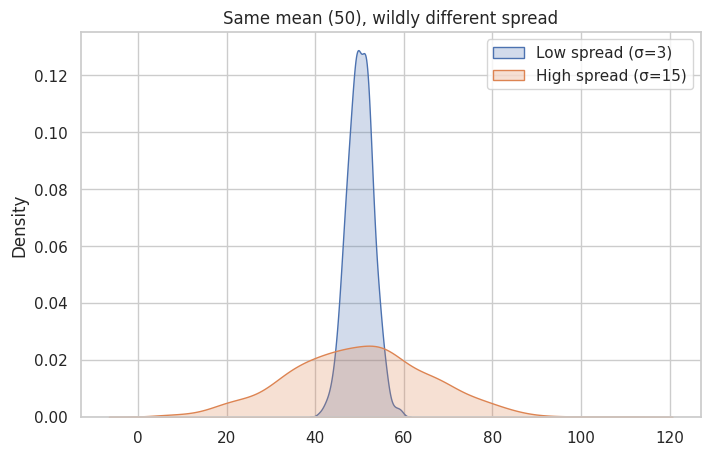

In [ ]:
low_spread = np.random.normal(loc=50, scale=3, size=1000)
high_spread = np.random.normal(loc=50, scale=15, size=1000)

for name, data in [("Low spread", low_spread), ("High spread", high_spread)]:
    print(f"{name:12s} | mean={np.mean(data):.1f}  std={np.std(data):.2f}  "
          f"IQR={np.percentile(data,75)-np.percentile(data,25):.2f}  "
          f"range={data.max()-data.min():.2f}")

fig, ax = plt.subplots()
sns.kdeplot(low_spread, fill=True, label="Low spread (σ=3)", ax=ax)
sns.kdeplot(high_spread, fill=True, label="High spread (σ=15)", ax=ax)
ax.set_title("Same mean (50), wildly different spread")
ax.legend()
plt.show()

### 🎨 Excalidraw Break #2 — The 68-95-99.7 Rule

Draw a single bell curve centered at 0. Then:

1. Shade the band from **−1σ to +1σ** in one color. Write "≈68%" above it.
2. Shade **−2σ to +2σ** (a wider band, lighter shade) and label it "≈95%".
3. Shade **−3σ to +3σ** (widest, lightest) and label it "≈99.7%".
4. Mark tick lines at −3σ, −2σ, −1σ, 0, +1σ, +2σ, +3σ along the x-axis.

This is the empirical rule for any normal distribution, and it's the mental model behind almost every "how unusual is this value" judgment call you'll ever make with real data.


In [ ]:
# Verifying the empirical rule with code instead of trust
data = np.random.normal(0, 1, 100_000)
for k in [1, 2, 3]:
    within = np.mean(np.abs(data) <= k)
    print(f"Within ±{k}σ: {within*100:.2f}% of the data")


Within ±1σ: 68.14% of the data
Within ±2σ: 95.42% of the data
Within ±3σ: 99.73% of the data


## 1.3 Shape: Skewness & Kurtosis

- **Skewness** measures asymmetry. Positive = tail stretches right, negative = tail stretches left, ≈0 = roughly symmetric.
- **Kurtosis** measures "tailedness" — how much of the variance comes from rare extreme values vs. frequent modest deviations. High kurtosis ("fat tails") means extreme events are more common than a normal distribution would predict — this is a big deal in finance and risk modeling.


In [ ]:
datasets = {
    "Normal": np.random.normal(0, 1, 5000),
    "Right-skewed": np.random.exponential(1, 5000),
    "Heavy-tailed (t-dist, df=3)": np.random.standard_t(3, 5000),
}
for name, d in datasets.items():
    print(f"{name:28s} | skew={stats.skew(d):6.2f}  kurtosis={stats.kurtosis(d):6.2f}")


Normal                       | skew=  0.03  kurtosis= -0.04
Right-skewed                 | skew=  2.24  kurtosis=  8.07
Heavy-tailed (t-dist, df=3)  | skew= 26.74  kurtosis=1419.84


## 🧪 Student Lab 1 — Descriptive Statistics

Fill in the `# TODO` cells below. Use the `tips` dataset (built into seaborn) — real restaurant bill data.


In [ ]:
tips = sns.load_dataset("tips")
tips.head()


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [ ]:
# TODO 1: Compute the mean, median, and standard deviation of `total_bill`.
# TODO 2: Is total_bill skewed? Compute skewness and say whether it's left, right, or symmetric.
# TODO 3: Compare the mean tip for smokers vs non-smokers. Which group tips more on average, and is the difference large relative to the spread (std) within each group?
# TODO 4: Plot a boxplot of total_bill grouped by day of week. Which day has the widest IQR?


---
# Part 2 — Probability Theory

**The core idea:** probability is a rulebook for reasoning under uncertainty. Descriptive statistics summarize data you *already have*. Probability theory lets you make principled statements about data you *don't have yet* — which is exactly the bridge you need to reach hypothesis testing in Part 3.


## 2.1 The Building Blocks

- A **sample space** $\Omega$ is the set of all possible outcomes (e.g. {H, T} for a coin).
- An **event** is a subset of the sample space (e.g. "rolling an even number" on a die = {2,4,6}).
- $P(A) \in [0,1]$, $P(\Omega)=1$.
- **Union rule:** $P(A \cup B) = P(A) + P(B) - P(A \cap B)$ — you subtract the overlap so you don't double-count it.
- **Conditional probability:** $P(A|B) = \dfrac{P(A \cap B)}{P(B)}$ — "given that B happened, how likely is A?"
- **Independence:** A and B are independent iff $P(A \cap B) = P(A)P(B)$, equivalently $P(A|B)=P(A)$ — knowing B happened tells you nothing new about A.


### 🎨 Excalidraw Break #3 — Venn Diagrams for Probability Rules

Draw a rectangle (the sample space Ω) containing two overlapping circles, A and B.

1. Shade the **union** $A \cup B$ (everything in either circle) in one drawing.
2. In a second drawing, shade only the **intersection** $A \cap B$ (the lens-shaped overlap).
3. In a third drawing, shade $A$ but with the overlap region cross-hatched differently — this is $P(A|B)$ visually: "of everything in B (just the B circle), what fraction is also in A?" Shrinking your attention to just circle B and asking what fraction is shaded is literally what conditional probability computes.

Label each diagram with its formula underneath.


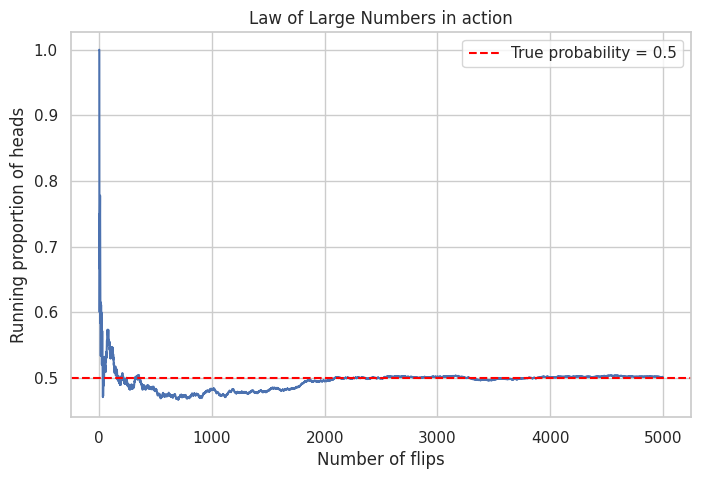

In [ ]:
# Law of Large Numbers: simulate a fair coin and watch the running average of heads converge to 0.5
n_flips = 5000
flips = np.random.binomial(1, 0.5, n_flips)
running_mean = np.cumsum(flips) / np.arange(1, n_flips + 1)

plt.plot(running_mean, color="#4C72B0")
plt.axhline(0.5, color="red", linestyle="--", label="True probability = 0.5")
plt.xlabel("Number of flips")
plt.ylabel("Running proportion of heads")
plt.title("Law of Large Numbers in action")
plt.legend()
plt.show()


## 2.2 Bayes' Theorem — updating beliefs with evidence

$$P(A|B) = \frac{P(B|A)\,P(A)}{P(B)}$$

This is the mathematically correct way to update a belief ($P(A)$, the **prior**) after observing evidence ($B$), producing $P(A|B)$, the **posterior**. It is the single most misunderstood formula in applied statistics — misreading it is *why* people misinterpret medical test results and p-values (a preview for Part 3).


In [ ]:
# Classic example: a disease test.
# Disease prevalence (prior): 1% of the population has the disease.
# Test sensitivity: 99% of sick people test positive.
# Test specificity: 95% of healthy people test negative (so 5% false positive rate).

p_disease = 0.01
p_pos_given_disease = 0.99
p_pos_given_healthy = 0.05  # false positive rate

p_pos = p_pos_given_disease * p_disease + p_pos_given_healthy * (1 - p_disease)
p_disease_given_pos = (p_pos_given_disease * p_disease) / p_pos

print(f"P(positive test)              = {p_pos:.4f}")
print(f"P(disease | positive test)    = {p_disease_given_pos:.4f}  <-- only ~{p_disease_given_pos*100:.1f}%!")


P(positive test)              = 0.0594
P(disease | positive test)    = 0.1667  <-- only ~16.7%!


Even with a 99%-accurate test, if you test positive you *still* only have about a 17% chance of actually having the disease — because the disease is rare, most positives come from the huge pool of healthy people triggering the 5% false-positive rate. This exact confusion — conflating $P(\text{positive}|\text{disease})$ with $P(\text{disease}|\text{positive})$ — is the same mistake people make when they read a p-value as "the probability the null hypothesis is true." Keep this in your back pocket for Part 3.


### 🎨 Excalidraw Break #4 — Bayes' Theorem as a Tree Diagram

Draw a probability tree:

1. Start with one root node splitting into two branches: **"Disease" (1%)** and **"Healthy" (99%)**.
2. From "Disease", branch into **"Test +" (99%)** and **"Test −" (1%)**.
3. From "Healthy", branch into **"Test +" (5%)** and **"Test −" (95%)**.
4. At each of the four leaf nodes, write the joint probability (multiply along the branch).
5. Circle the two "Test +" leaves and write underneath: $P(\text{Disease}|+) = \dfrac{\text{Disease∩+}}{\text{Disease∩+} + \text{Healthy∩+}}$.

Seeing the tiny "Disease ∩ +" sliver next to the much bigger "Healthy ∩ +" sliver makes the surprising 17% answer feel obvious instead of paradoxical.


## 2.3 Probability Distributions — the shapes uncertainty takes

| Distribution | Models... | Key parameter(s) |
|---|---|---|
| **Bernoulli / Binomial** | Number of successes in *n* yes/no trials | *n*, *p* |
| **Poisson** | Count of rare events in a fixed interval (calls per hour, defects per batch) | *λ* (rate) |
| **Normal (Gaussian)** | Sums of many small independent effects (heights, measurement error) | *μ*, *σ* |
| **Uniform** | "Anything in this range is equally likely" | *a*, *b* |


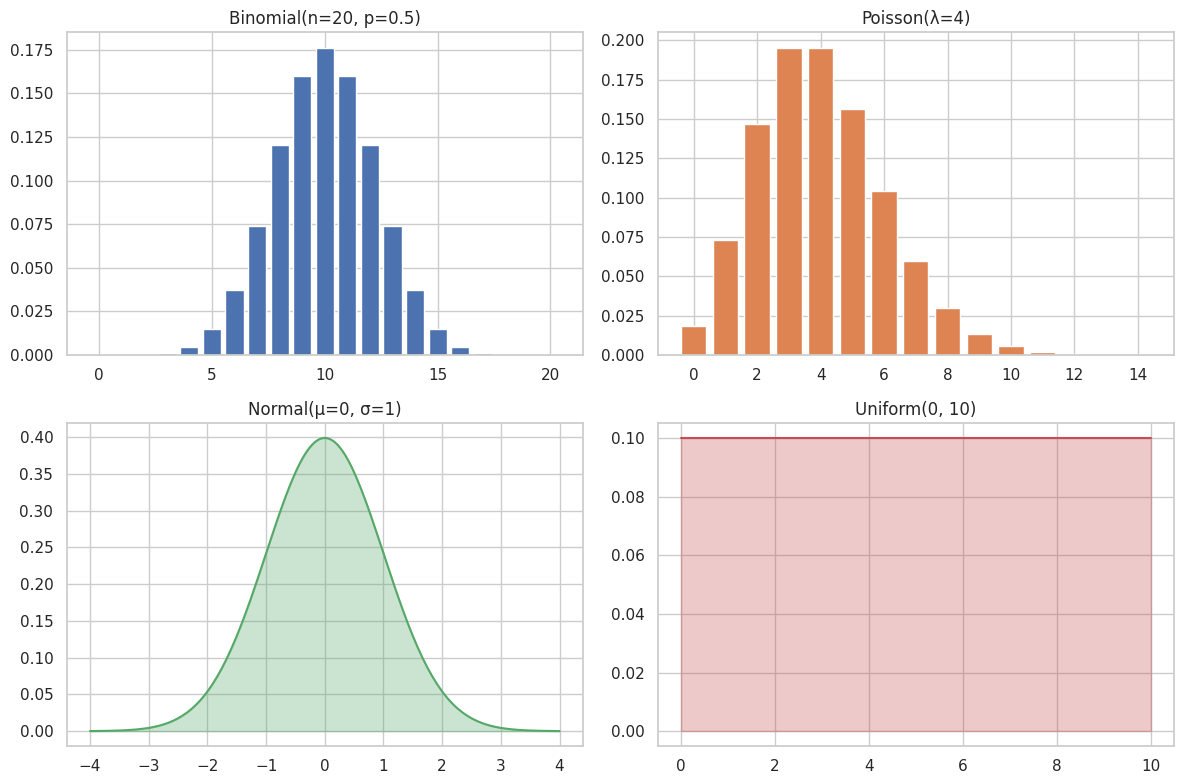

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Binomial: 20 coin flips, p=0.5
x = np.arange(0, 21)
axes[0,0].bar(x, stats.binom.pmf(x, 20, 0.5), color="#4C72B0")
axes[0,0].set_title("Binomial(n=20, p=0.5)")

# Poisson: average 4 customer arrivals per minute
x = np.arange(0, 15)
axes[0,1].bar(x, stats.poisson.pmf(x, 4), color="#DD8452")
axes[0,1].set_title("Poisson(λ=4)")

# Normal
x = np.linspace(-4, 4, 200)
axes[1,0].plot(x, stats.norm.pdf(x, 0, 1), color="#55A868")
axes[1,0].fill_between(x, stats.norm.pdf(x, 0, 1), alpha=0.3, color="#55A868")
axes[1,0].set_title("Normal(μ=0, σ=1)")

# Uniform
x = np.linspace(0, 10, 200)
axes[1,1].plot(x, stats.uniform.pdf(x, 0, 10), color="#C44E52")
axes[1,1].fill_between(x, stats.uniform.pdf(x, 0, 10), alpha=0.3, color="#C44E52")
axes[1,1].set_title("Uniform(0, 10)")

plt.tight_layout()
plt.show()


### 🎨 Excalidraw Break #5 — The Central Limit Theorem (CLT)

This is arguably the single most important idea bridging Part 2 and Part 3. Draw three rows:

1. **Row 1:** a wildly non-normal shape — draw a skewed blob or even a bimodal (two-humped) shape. Label it "population distribution (any shape)".
2. **Row 2:** draw 5 small stick-figure "samples" being pulled out of Row 1, each an arrow pointing down to a small dot labeled with an "x̄" (sample mean).
3. **Row 3:** draw a clean, symmetric bell curve made of *those dots* piling up. Label it "distribution of sample means → approximately Normal, regardless of Row 1's shape, as sample size grows".

This is the CLT: no matter how ugly your original data is, the *average* of many samples behaves like a normal distribution. It's the reason t-tests and z-tests (Part 3) are allowed to assume normality even when raw data isn't normal.


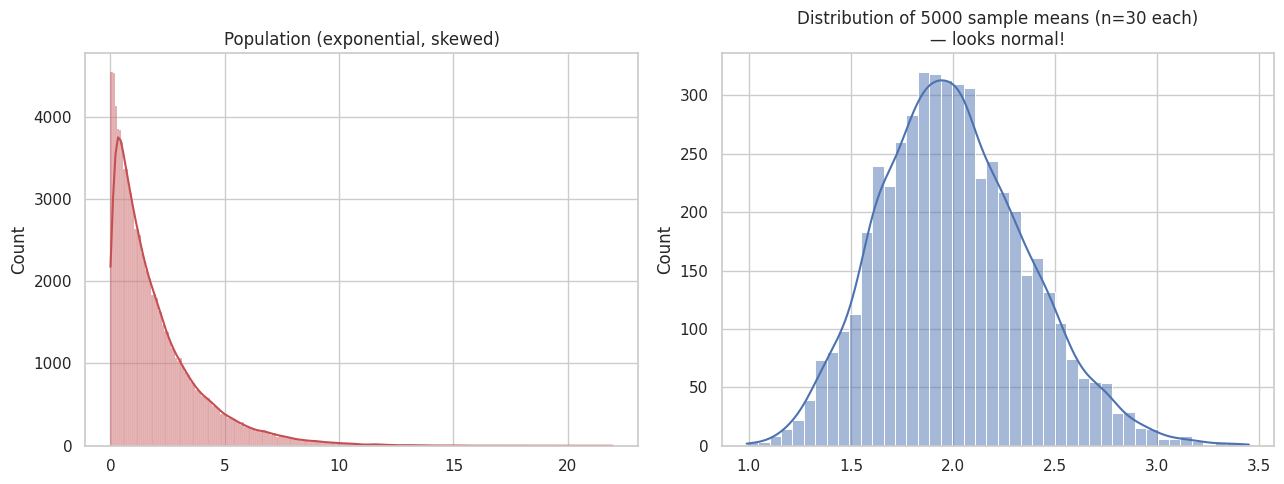

In [ ]:
# Demonstrating CLT: population is heavily skewed (exponential), but sample means are ~normal
population = np.random.exponential(scale=2, size=100_000)

sample_means = [np.mean(np.random.choice(population, size=30)) for _ in range(5000)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(population, ax=axes[0], color="#C44E52", kde=True)
axes[0].set_title("Population (exponential, skewed)")

sns.histplot(sample_means, ax=axes[1], color="#4C72B0", kde=True)
axes[1].set_title("Distribution of 5000 sample means (n=30 each)\n— looks normal!")
plt.tight_layout()
plt.show()


## 🧪 Student Lab 2 — Probability Theory



In [ ]:
# TODO 1: A factory produces defective items at a rate of 2% (Bernoulli p=0.02).
#          In a batch of 50 items, what is the probability of exactly 0 defects? Use stats.binom.

# TODO 2: Simulate rolling two fair six-sided dice 10,000 times. Empirically estimate
#          P(sum == 7) and compare it to the theoretical value (6/36).

# TODO 3: A website gets an average of 3 signups per hour (Poisson). What's the probability
#          of getting 6 or more signups in a given hour? Use stats.poisson.sf (survival function).

# TODO 4: Take 1000 samples of size 50 from a *uniform* distribution (any shape you like) and
#          plot the histogram of the sample means. Confirm it looks approximately normal (CLT).



---
# Part 3 — Hypothesis Testing

**The core idea:** you have a claim about the world (e.g. "this new drug lowers blood pressure") and a limited, noisy sample of data. Hypothesis testing is a formal procedure for deciding whether your data provides *enough evidence* to believe the claim, while controlling how often you'd be fooled by random chance.


## 3.1 The Logic (this is the part everyone skips and later regrets)

1. **Null hypothesis ($H_0$):** the "boring", skeptical default — usually "no effect" or "no difference". e.g. $H_0: \mu_{\text{drug}} = \mu_{\text{placebo}}$.
2. **Alternative hypothesis ($H_1$):** what you suspect might actually be true. e.g. $H_1: \mu_{\text{drug}} \neq \mu_{\text{placebo}}$.
3. **Test statistic:** a number computed from your data (t-statistic, z-statistic, chi-square, etc.) that measures how far your sample is from what $H_0$ predicts.
4. **p-value:** *assuming $H_0$ is true*, the probability of seeing a test statistic at least this extreme, purely by random chance.
5. **Significance level ($\alpha$)**, typically 0.05: your pre-agreed threshold. If p-value < α, you **reject $H_0$**.

### The two ways to be wrong

| | $H_0$ is actually True | $H_0$ is actually False |
|---|---|---|
| **You reject $H_0$** | ❌ Type I Error (false positive), rate = α | ✅ Correct (True Positive) |
| **You fail to reject $H_0$** | ✅ Correct (True Negative) | ❌ Type II Error (false negative), rate = β |

**Critical misconception to kill right now:** the p-value is **NOT** "the probability that $H_0$ is true." It's $P(\text{data this extreme} \mid H_0 \text{ true})$ — exactly the same $P(B|A)$ vs. $P(A|B)$ trap from Bayes' theorem in Part 2. A p-value of 0.03 does not mean there's a 3% chance the null is true; it means "if there really were no effect, data this extreme would show up only 3% of the time."


### 🎨 Excalidraw Break #6 — Rejection Regions and the Two Error Types

Draw a single bell curve representing the sampling distribution of your test statistic **under $H_0$**, centered at 0.

1. Shade the two tails beyond some critical value (±1.96 for α=0.05, two-tailed) in **red** — label this "rejection region, area = α = 0.05".
2. Now draw a *second*, shifted bell curve slightly to the right of the first, representing the true distribution *if $H_1$ is actually true*.
3. Shade the part of the **second** curve that falls *inside* the "fail to reject" zone of the first curve, in **blue** — that sliver is β, the Type II error rate.
4. Shade the part of the **first** curve past the critical value in **red** again for clarity — that's α, the Type I error rate.

Seeing both curves overlapping like this is the entire intuition behind statistical power (1−β): the more the two curves separate — bigger true effect, bigger sample size, less noise — the smaller that blue sliver gets.


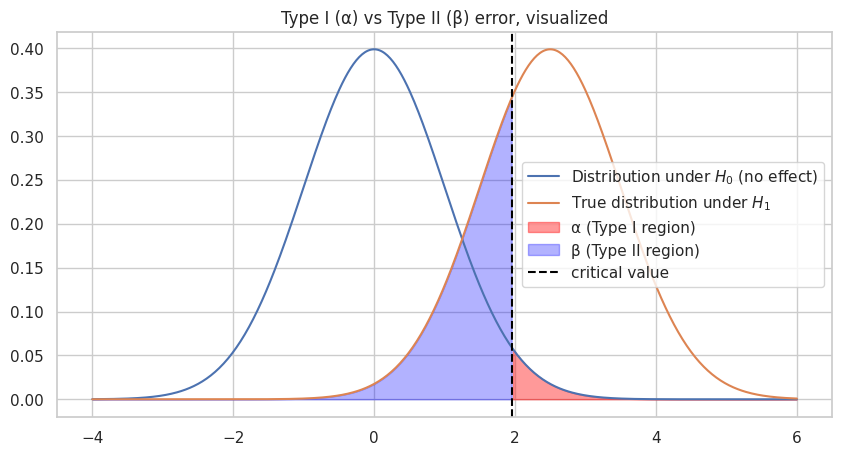

In [ ]:
# Visualizing the same idea in code
x = np.linspace(-4, 6, 500)
h0_dist = stats.norm(0, 1)
h1_dist = stats.norm(2.5, 1)  # true effect exists, shifted mean

critical_value = stats.norm.ppf(0.975)  # two-tailed alpha=0.05

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, h0_dist.pdf(x), label="Distribution under $H_0$ (no effect)", color="#4C72B0")
ax.plot(x, h1_dist.pdf(x), label="True distribution under $H_1$", color="#DD8452")

x_reject = x[x > critical_value]
ax.fill_between(x_reject, h0_dist.pdf(x_reject), color="red", alpha=0.4, label="α (Type I region)")

x_beta = x[x < critical_value]
ax.fill_between(x_beta, h1_dist.pdf(x_beta), color="blue", alpha=0.3, label="β (Type II region)")

ax.axvline(critical_value, color="black", linestyle="--", label="critical value")
ax.legend()
ax.set_title("Type I (α) vs Type II (β) error, visualized")
plt.show()


## 3.2 Running a Real Test: the One-Sample & Two-Sample t-test

**Scenario:** a coffee shop claims their average wait time is 3 minutes. You time 40 customers and want to know if the real average is different.


In [ ]:
true_wait_time = 3.4       # the real (unknown, "God's-eye-view") mean, slightly higher than claimed
observed = np.random.normal(true_wait_time, scale=1.1, size=40)

t_stat, p_value = stats.ttest_1samp(observed, popmean=3.0)

print(f"Sample mean wait time : {observed.mean():.2f} minutes")
print(f"t-statistic           : {t_stat:.3f}")
print(f"p-value               : {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print(f"\np < {alpha} -> REJECT H0. Evidence the true wait time differs from 3 minutes.")
else:
    print(f"\np >= {alpha} -> FAIL TO REJECT H0. Not enough evidence to say it differs from 3 minutes.")


Sample mean wait time : 3.11 minutes
t-statistic           : 0.627
p-value               : 0.5341

p >= 0.05 -> FAIL TO REJECT H0. Not enough evidence to say it differs from 3 minutes.


**Two-sample version:** are two independent groups actually different? (e.g. wait times at Location A vs Location B)


Mean A = 3.00, Mean B = 3.78
t = -3.926, p = 0.0002


/tmp/ipykernel_579/3431856790.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Location A", "Location B"])


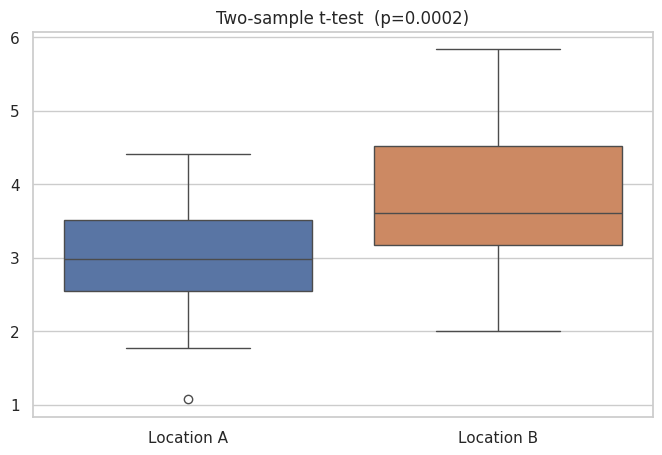

In [ ]:
location_a = np.random.normal(3.0, 1.0, 35)
location_b = np.random.normal(3.6, 1.0, 35)

t_stat, p_value = stats.ttest_ind(location_a, location_b)
print(f"Mean A = {location_a.mean():.2f}, Mean B = {location_b.mean():.2f}")
print(f"t = {t_stat:.3f}, p = {p_value:.4f}")

fig, ax = plt.subplots()
sns.boxplot(data=[location_a, location_b], ax=ax)
ax.set_xticklabels(["Location A", "Location B"])
ax.set_title(f"Two-sample t-test  (p={p_value:.4f})")
plt.show()


## 3.3 Confidence Intervals — the honest cousin of the p-value

A p-value gives you a binary yes/no. A **confidence interval (CI)** gives you a *range* of plausible values for the true parameter, which is usually far more useful. A 95% CI means: "if we repeated this sampling process many times, 95% of the intervals we'd construct this way would contain the true population mean."

(Note the careful wording — it is **not** "there's a 95% chance the true mean is in this specific interval." The true mean is fixed; it's the *interval construction procedure* that has the 95% success rate. Same P(A|B) vs P(B|A) trap as before, wearing a different hat.)


In [ ]:
sample = observed  # reuse the coffee shop sample from earlier
mean = sample.mean()
sem = stats.sem(sample)  # standard error of the mean
ci_low, ci_high = stats.t.interval(0.95, df=len(sample)-1, loc=mean, scale=sem)

print(f"Sample mean: {mean:.2f}")
print(f"95% Confidence Interval: [{ci_low:.2f}, {ci_high:.2f}]")
print("Note: 3.0 minutes (the claimed value) is " +
      ("inside" if ci_low <= 3.0 <= ci_high else "outside") + " this interval.")


Sample mean: 3.11
95% Confidence Interval: [2.75, 3.47]
Note: 3.0 minutes (the claimed value) is inside this interval.


### 🎨 Excalidraw Break #7 — Confidence Intervals as Repeated Sampling

Draw a horizontal line representing the true (unknown) population mean μ as a vertical dashed line.

1. Below it, draw **20 horizontal bars** (like error bars), each representing a 95% CI from a *different* random sample of the same population.
2. Roughly 19 of the 20 bars should cross the dashed μ line; deliberately draw **1 bar that misses it entirely**.
3. Label the drawing: "In the long run, about 95% of these intervals capture the true μ — you just never know, for any single interval you compute, whether it's one of the lucky 19 or the unlucky 1."

This picture is the antidote to the single most common CI misinterpretation.


## 3.4 Chi-Square Test — for categorical data

t-tests compare *means* of numeric data. When your data is categorical (counts in buckets), you use a **chi-square test** instead — e.g. "is there an association between customer age group and preferred product?"


In [ ]:
# Observed counts: rows = age group, columns = product preference
observed_table = pd.DataFrame(
    [[50, 30, 20],
     [20, 40, 40],
     [10, 20, 70]],
    index=["18-25", "26-40", "41+"],
    columns=["Product A", "Product B", "Product C"]
)
print("Observed counts:")
print(observed_table)

chi2, p, dof, expected = stats.chi2_contingency(observed_table)
print(f"\nChi-square statistic: {chi2:.2f}")
print(f"Degrees of freedom   : {dof}")
print(f"p-value              : {p:.5f}")
print("\n-> " + ("There IS a significant association between age group and product preference."
                  if p < 0.05 else "No significant association detected."))


Observed counts:
       Product A  Product B  Product C
18-25         50         30         20
26-40         20         40         40
41+           10         20         70

Chi-square statistic: 68.40
Degrees of freedom   : 4
p-value              : 0.00000

-> There IS a significant association between age group and product preference.


## 🧪 Student Lab 3 — Hypothesis Testing



In [ ]:
# TODO 1: A cereal box claims 500g of contents. You weigh 25 boxes and want to test if the
#          true mean differs from 500g. Simulate 25 samples from N(495, 8) and run a one-sample
#          t-test against popmean=500. State your conclusion in a comment.

# TODO 2: Two ad campaigns (A and B) report click-through data. Simulate:
#             campaign_a = np.random.binomial(1, 0.10, 500)   # 10% click rate
#             campaign_b = np.random.binomial(1, 0.13, 500)   # 13% click rate
#          Run a two-sample t-test (or a proportions z-test if you want to look one up)
#          comparing campaign_a and campaign_b. Is the difference statistically significant?

# TODO 3: Compute and print a 95% confidence interval for the mean click rate of campaign_b.

# TODO 4: Build your own 2x2 contingency table (e.g. "smoker vs non-smoker" x "disease vs no disease")
#          with made-up counts, and run stats.chi2_contingency on it. Interpret the p-value.



---
# 🎓 Capstone — Putting It All Together

**Scenario:** You work for an e-commerce company. Marketing claims a new checkout page design increases average order value (AOV). You have transaction data from the *old* page and the *new* page (simulated below).

Your job: walk through all three parts on this single dataset.


In [ ]:
np.random.seed(7)
old_page = np.random.gamma(shape=4, scale=15, size=400)      # old design orders
new_page = np.random.gamma(shape=4.3, scale=15.5, size=420)  # new design orders (slightly higher)

df = pd.DataFrame({
    "order_value": np.concatenate([old_page, new_page]),
    "page_version": ["old"] * len(old_page) + ["new"] * len(new_page)
})
df.head()


,order_value,page_version
0,119.247746,old
1,42.673108,old
2,35.309448,old
3,55.059350,old
4,89.713912,old


                   mean     median        std      skew
page_version                                           
new           67.518675  62.190699  31.182788  0.783292
old           57.484857  52.958239  28.001896  0.871374


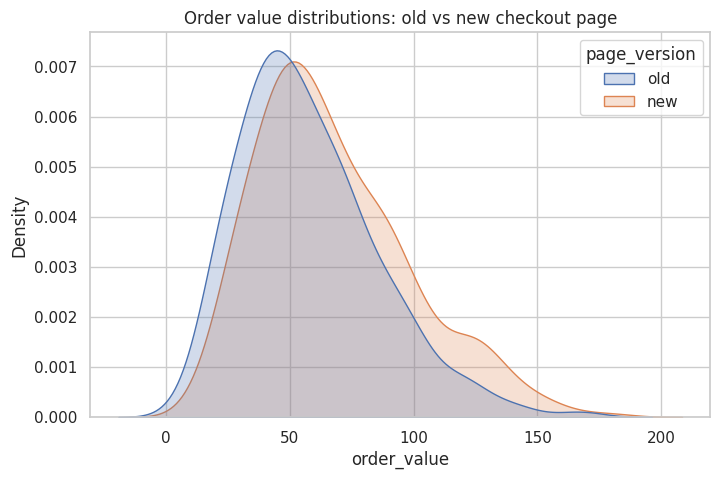

In [ ]:
# STEP 1 — Descriptive Statistics: summarize both groups
summary = df.groupby("page_version")["order_value"].agg(["mean", "median", "std", "skew"])
print(summary)

fig, ax = plt.subplots()
sns.kdeplot(data=df, x="order_value", hue="page_version", fill=True, ax=ax)
ax.set_title("Order value distributions: old vs new checkout page")
plt.show()


**Discuss:** Are the distributions symmetric or skewed? Does the mean or median feel like the more trustworthy summary here? (Hint: revisit Excalidraw Break #1.)


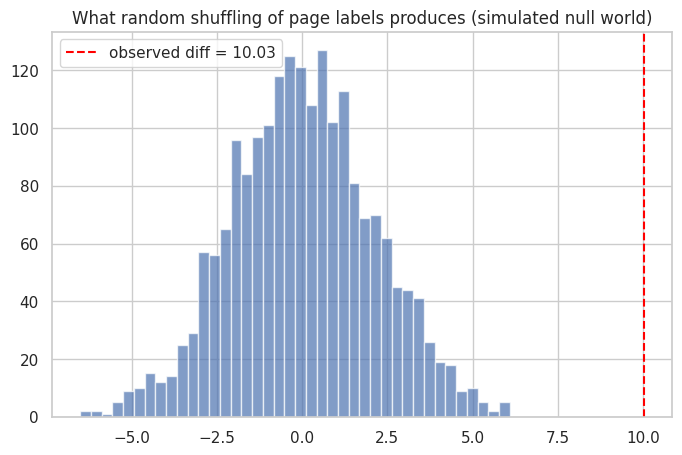

Observed difference in means: 10.03
P(random shuffle produces a diff this extreme): 0.0000


In [ ]:
# STEP 2 — Probability: if there were truly NO difference between pages, how surprising
# would a gap this large be, purely due to sampling randomness? This is exactly the CLT
# (Excalidraw Break #5) at work: even though gamma-distributed order values are skewed,
# the *sample means* of 400+ orders behave approximately normally, which is what licenses
# using a t-test in Step 3.

boot_diffs = []
combined = df["order_value"].values
n_old, n_new = len(old_page), len(new_page)
for _ in range(2000):
    shuffled = np.random.permutation(combined)
    boot_diffs.append(shuffled[:n_new].mean() - shuffled[n_new:].mean())

observed_diff = new_page.mean() - old_page.mean()
plt.hist(boot_diffs, bins=40, color="#4C72B0", alpha=0.7)
plt.axvline(observed_diff, color="red", linestyle="--", label=f"observed diff = {observed_diff:.2f}")
plt.title("What random shuffling of page labels produces (simulated null world)")
plt.legend()
plt.show()

print(f"Observed difference in means: {observed_diff:.2f}")
print(f"P(random shuffle produces a diff this extreme): "
      f"{np.mean(np.abs(boot_diffs) >= abs(observed_diff)):.4f}")


In [ ]:
# STEP 3 — Hypothesis Testing: formal t-test + confidence interval on the difference
t_stat, p_value = stats.ttest_ind(new_page, old_page)
diff = new_page.mean() - old_page.mean()
se_diff = np.sqrt(new_page.var(ddof=1)/len(new_page) + old_page.var(ddof=1)/len(old_page))
ci = stats.norm.interval(0.95, loc=diff, scale=se_diff)

print(f"H0: mean(new) - mean(old) = 0")
print(f"H1: mean(new) - mean(old) != 0")
print(f"Observed difference       : {diff:.2f}")
print(f"t-statistic               : {t_stat:.3f}")
print(f"p-value                   : {p_value:.5f}")
print(f"95% CI for the difference : [{ci[0]:.2f}, {ci[1]:.2f}]")

alpha = 0.05
print("\nConclusion:", "Reject H0 — the new page appears to genuinely increase AOV."
      if p_value < alpha else "Fail to reject H0 — not enough evidence of a real difference.")


H0: mean(new) - mean(old) = 0
H1: mean(new) - mean(old) != 0
Observed difference       : 10.03
t-statistic               : 4.840
p-value                   : 0.00000
95% CI for the difference : [5.98, 14.09]

Conclusion: Reject H0 — the new page appears to genuinely increase AOV.


### 🎨 Excalidraw Break #8 (Capstone) — The Full Pipeline as One Diagram

Draw a horizontal flowchart with four boxes connected by arrows:

`[ Raw transaction data ]` → `[ Descriptive stats: means, spread, skew ]` → `[ Probability model: what does "random chance alone" look like? ]` → `[ Hypothesis test: is the observed gap bigger than random chance would produce? ]`

Underneath the whole chain, write one sentence in your own words explaining how each box depends on the one before it. This is the picture to keep in your head every time you see a headline claiming "Study finds X causes Y" — every one of those claims implicitly walked this same four-box pipeline (or should have).


---
# 📎 Cheat Sheet

**Descriptive Statistics**
- Mean sensitive to outliers; median robust; compare them to detect skew.
- Std dev / variance / IQR all answer "how spread out is this?" — pick based on outlier sensitivity.
- Skewness sign tells you which way the tail points; mean chases the tail.

**Probability Theory**
- $P(A|B) = P(A\cap B)/P(B)$ — conditioning restricts your universe to B, then asks what fraction is A.
- Bayes' theorem flips a conditional around: $P(A|B) = P(B|A)P(A)/P(B)$.
- CLT: averages of *anything* become approximately normal as sample size grows — this is why so many tests get to assume normality.

**Hypothesis Testing**
- p-value = P(data this extreme | H0 true), **never** P(H0 true | data).
- α = your tolerance for false positives (Type I); β = false negative rate (Type II); power = 1−β.
- Confidence intervals describe the *procedure's* long-run success rate, not the probability that one specific interval contains the truth.
- t-test → numeric means; chi-square → categorical association.

**All 8 Excalidraw sketches, if you did them, now live in your hand-drawing history as a personal reference sheet more useful than this cheat sheet. Go back and photograph them into one folder.**
